In [1]:
import numpy as np

path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/checkpoints/class_1/ksvd_checkpoint.npz"

data = np.load(path)

print(data.files)  # list stored arrays

for key in data.files:
    print(key, data[key].shape)

['D', 'Gamma', 'unused', 'replaced', 'errors_', 'completed_iter', 'n_iter', 'n_components', 'n_nonzero_coefs', 'n_features', 'n_samples', 'n_frozen']
D (1728, 10368)
Gamma (10368, 27196)
unused (27196,)
replaced (10368,)
errors_ (10,)
completed_iter ()
n_iter ()
n_components ()
n_nonzero_coefs ()
n_features ()
n_samples ()
n_frozen ()


In [2]:
print(data["completed_iter"])
print(data["errors_"])

10
[0.07476985 0.06978924 0.068795   0.06777526 0.06787974 0.0673127
 0.06751534 0.06709298 0.06731582 0.0669922 ]


In [3]:
import numpy as np
import pickle

# Path to trained dictionary
dict_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl"

# Load dictionary model
with open(dict_path, "rb") as f:
    model_data = pickle.load(f)

# Extract dictionary matrix
D = model_data["model"].D_

print("Dictionary loaded successfully")
print("Dictionary shape:", D.shape)
print("Dictionary dtype:", D.dtype)

# Load sparse codes
path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz"

data = np.load(path)

Gamma = data["Gamma"]
labels = data["labels"]

print("Gamma shape:", Gamma.shape)
print("Labels shape:", labels.shape)

classes = np.unique(labels)

Dictionary loaded successfully
Dictionary shape: (1728, 12096)
Dictionary dtype: float32


FileNotFoundError: [Errno 2] No such file or directory: '/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz'

# Atom Matrix

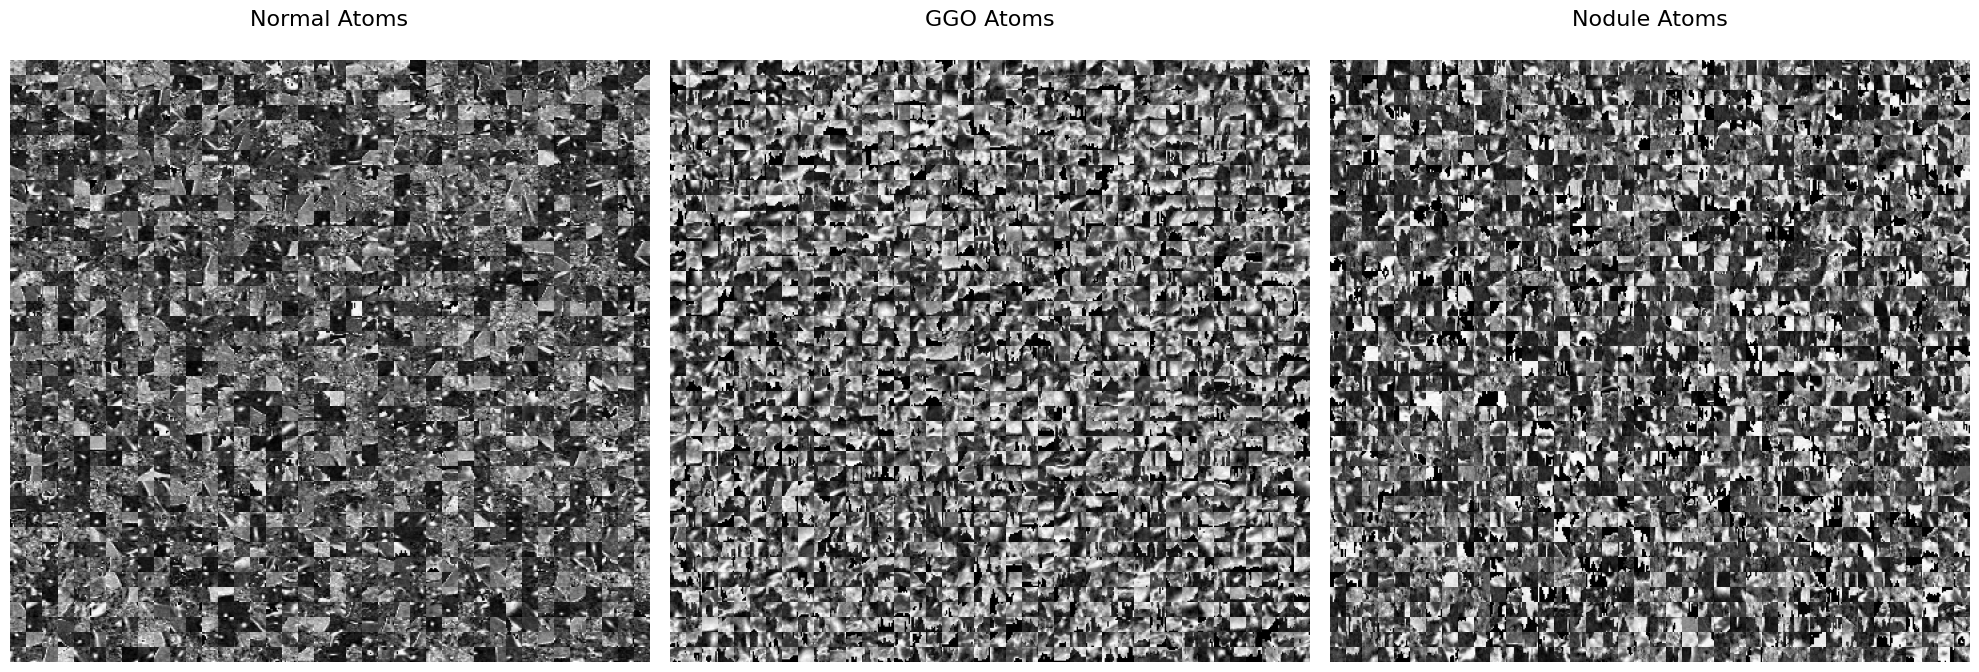

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

D = pickle.load(
    open(
        "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
        "rb"
    ))["model"].D_

PATCH_SIZE = 12
MIDDLE = PATCH_SIZE // 2

rng = np.random.default_rng(42)

GRID_SIZE = 40
N_ATOMS = GRID_SIZE * GRID_SIZE  # 900

normal_atoms = rng.choice(
    np.arange(0, 6812),
    size=N_ATOMS,
    replace=False
)

ggo_atoms = rng.choice(
    np.arange(6912, 10368),
    size=N_ATOMS,
    replace=False
)

nodule_atoms = rng.choice(
    np.arange(10368, 12096),
    size=N_ATOMS,
    replace=False
)

def plot_grid(fig, left, right, atom_ids, title):

    gs = fig.add_gridspec(
        GRID_SIZE,
        GRID_SIZE,
        left=left,
        right=right,
        top=0.88,
        bottom=0.02,
        wspace=0,
        hspace=0
    )

    axes = []

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            ax = fig.add_subplot(gs[i, j])
            ax.axis("off")
            axes.append(ax)

    fig.text(
        (left + right) / 2,
        0.93,
        title,
        ha="center",
        fontsize=16
    )

    for ax, atom_id in zip(axes, atom_ids):
        atom = D[:, atom_id].reshape(
            PATCH_SIZE,
            PATCH_SIZE,
            PATCH_SIZE
        )

        ax.imshow(atom[MIDDLE], cmap="gray")
        ax.axis("off")


fig = plt.figure(figsize=(20, 7))


# Normal atoms
plot_grid(
    fig,
    0.01,
    0.33,
    normal_atoms,
    "Normal Atoms"
)


# GGO atoms
plot_grid(
    fig,
    0.34,
    0.66,
    ggo_atoms,
    "GGO Atoms"
)


# Nodule atoms
plot_grid(
    fig,
    0.67,
    0.99,
    nodule_atoms,
    "Nodule Atoms"
)


plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("Dictionary shape:", D.shape)

reconstructed_patches = {}

# Create one figure for all classes
fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(15,5)
)

for i, cls in enumerate(classes):

    Gamma_cls = Gamma[:, labels == cls]

    # Mean absolute coefficient values
    mean_abs_coefficients = np.mean(
        np.abs(Gamma_cls),
        axis=1
    )

    # Top 10 coefficient indices
    top10_idx = np.argsort(
        mean_abs_coefficients
    )[::-1][:10]


    # Average signed coefficient values
    top10_values = np.mean(
        Gamma_cls[top10_idx, :],
        axis=1
    )


    print("\n==============================")
    print(f"Class {cls}")
    print("Top coefficients")

    for idx, value in zip(top10_idx, top10_values):
        print(
            f"Index {idx:5d} | Mean coefficient {value:.6f}"
        )


    # Reconstruction
    D_selected = D[:, top10_idx]

    reconstructed = D_selected @ top10_values

    reconstructed = reconstructed.reshape(12,12,12)

    reconstructed_patches[cls] = reconstructed


    print("Reconstructed patch shape:", reconstructed.shape)


    # Middle slice
    mid = reconstructed.shape[2] // 2

    axes[i].imshow(
        reconstructed[:, :, mid],
        cmap="gray"
    )

    axes[i].set_title(
        f"Class {cls}"
    )

    axes[i].axis("off")


plt.suptitle(
    "Class-wise Reconstruction from Top-10 Sparse Coefficients",
    fontsize=15
)

plt.tight_layout()
plt.show()

Dictionary shape: (1728, 12096)


NameError: name 'classes' is not defined

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_3d_patch_subplot(ax, volume, title, threshold=None):

    if threshold is None:
        threshold = np.percentile(
            np.abs(volume),
            70
        )

    mask = np.abs(volume) > threshold

    x, y, z = np.where(mask)
    values = volume[mask]

    ax.scatter(
        x,
        y,
        z,
        s=60,
        c=values,
        cmap="gray"
    )

    ax.set_title(title)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")


# Create one figure
fig = plt.figure(figsize=(18,6))

for i, cls in enumerate([0, 1, 2]):

    patch = reconstructed_patches[cls]

    ax = fig.add_subplot(
        1,
        3,
        i+1,
        projection="3d"
    )

    plot_3d_patch_subplot(
        ax,
        patch,
        title=f"Class {cls}"
    )


plt.suptitle(
    "3D Reconstruction from Top-10 Sparse Coefficients",
    fontsize=16
)

plt.tight_layout()
plt.show()

KeyError: 0

<Figure size 1800x600 with 0 Axes>

['Gamma', 'labels']
Indices:
[11751 11752 11753 11754 11755 11756 11757 11758 11759 11760 11761 11762]

Coordinates:
[[ 61 158 116]
 [ 61 158 120]
 [ 65 154 116]
 [ 65 154 120]
 [ 65 158 112]
 [ 65 158 116]
 [ 65 158 120]
 [ 65 162 116]
 [ 65 162 120]
 [ 69 158 116]
 [ 69 158 120]
 [ 69 162 116]]
(1728, 12)
(12, 12, 12, 12)


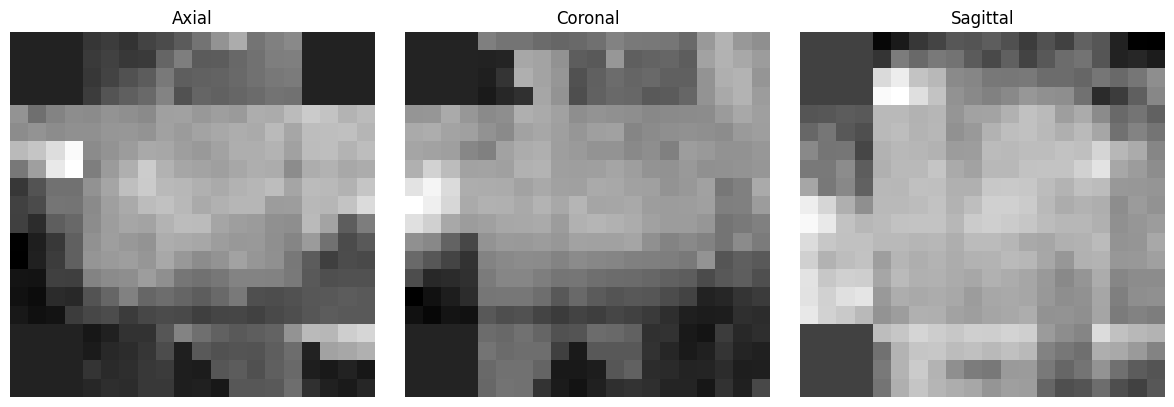

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model_data = pickle.load(f)

ksvd = model_data["model"]
D = ksvd.D_

sparse_codes = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz",
    allow_pickle=True
)
print(sparse_codes.files)

patch_data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

X = patch_data["X"]
scan_ids = patch_data["scan_ids"]
coords = patch_data["coords"]
H = patch_data["H"]

target_scan = "train_11150_b_2"

Gamma = sparse_codes["Gamma"]
labels = sparse_codes["labels"]

# Find the patches that actually belong to the target scan
indices = np.where(scan_ids == target_scan)[0]

print("Indices:")
print(indices)

print("\nCoordinates:")
print(coords[indices])

# Reconstruct exactly those patches, using the same indices
gamma = Gamma[:, indices]
reconstructed = D @ gamma

print(reconstructed.shape)

patches = reconstructed.T.reshape(-1, 12, 12, 12)
print(patches.shape)

min_coord = coords[indices].min(axis=0)
max_coord = coords[indices].max(axis=0)

shape = tuple(max_coord - min_coord + 12)

volume = np.zeros(shape)
weight = np.zeros(shape)

for patch, coord in zip(patches, coords[indices]):
    x, y, z = coord - min_coord
    volume[x:x+12, y:y+12, z:z+12] += patch
    weight[x:x+12, y:y+12, z:z+12] += 1

volume /= np.maximum(weight, 1)

# Visualize the reconstructed volume
cx, cy, cz = np.array(volume.shape) // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(volume[:, :, cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(volume[:, cy, :], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx, :, :], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model = pickle.load(f)

ksvd = model["model"]
D = ksvd.D_


# Take top 4 atoms from previous calculation
top_4_atoms = top_10_atoms[:10]

print("Top 4 atoms:", top_4_atoms)


# Aggregate coefficient for each selected atom
# (sum of signed coefficients across all patches)
atom_coefficients = np.sum(
    Gamma_patches[top_4_atoms, :],
    axis=1
)

print("\nAtom coefficients:")
for atom, coef in zip(top_4_atoms, atom_coefficients):
    print(f"Atom {atom}: {coef:.6f}")


# Reconstruct contribution of each atom
# D[:, atom] * coefficient
atom_contributions = []

for atom, coef in zip(top_4_atoms, atom_coefficients):

    patch = D[:, atom] * coef

    atom_contributions.append(
        patch
    )


# Superimpose the 4 atom contributions
combined_patch = np.sum(
    atom_contributions,
    axis=0
)


print("\nCombined patch shape:", combined_patch.shape)


# Convert to 3D
combined_patch_3d = combined_patch.reshape(
    16,16,16
)


# Visualize
mid = 8

fig, axes = plt.subplots(
    1,3,
    figsize=(12,4)
)

axes[0].imshow(
    combined_patch_3d[:,:,mid],
    cmap="gray"
)
axes[0].set_title("Axial")

axes[1].imshow(
    combined_patch_3d[:,mid,:],
    cmap="gray"
)
axes[1].set_title("Coronal")

axes[2].imshow(
    combined_patch_3d[mid,:,:],
    cmap="gray"
)
axes[2].set_title("Sagittal")


for ax in axes:
    ax.axis("off")

plt.suptitle(
    "Reconstruction from Top 4 Dictionary Atoms"
)

plt.show()

NameError: name 'top_10_atoms' is not defined

# Reconstruction

Dictionary shape: (1728, 12096)
Reconstructed patch shape: (1728,)


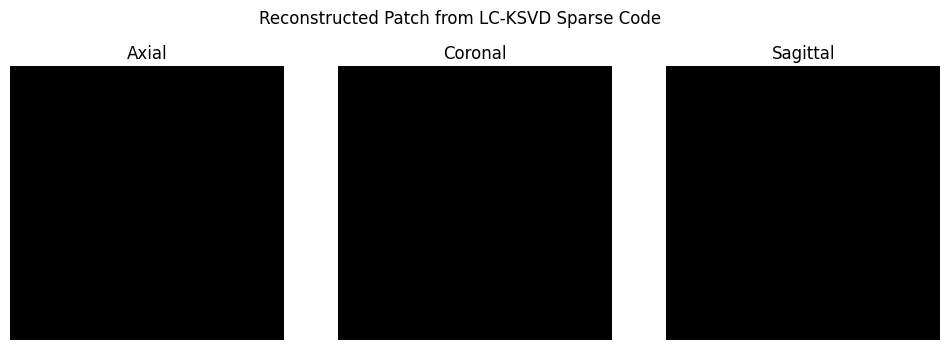

In [11]:
ksvd = model["model"]
D = ksvd.D_

idx = 97991
gamma = Gamma[:, idx]

reconstructed_patch = D @ gamma

print("Dictionary shape:", D.shape)
print("Reconstructed patch shape:", reconstructed_patch.shape)

patch_3d = reconstructed_patch.reshape(12, 12, 12)

import matplotlib.pyplot as plt

# Choose center slices
mid = 8

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Axial view
axes[0].imshow(
    patch_3d[:, :, mid],
    cmap="gray"
)
axes[0].set_title("Axial")

# Coronal view
axes[1].imshow(
    patch_3d[:, mid, :],
    cmap="gray"
)
axes[1].set_title("Coronal")

# Sagittal view
axes[2].imshow(
    patch_3d[mid, :, :],
    cmap="gray"
)
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis("off")

plt.suptitle("Reconstructed Patch from LC-KSVD Sparse Code")
plt.show()

In [ ]:
# Assumed sparse code indices
gamma_indices = np.arange(11751, 11762)

# Extract the 12 sparse codes
gamma = Gamma[:, gamma_indices]
ksvd = model["model"]
D = ksvd.D_
# Reconstruct all patches
reconstructed = D @ gamma

print(reconstructed.shape)

patches = reconstructed.T.reshape(-1, 12, 12, 12)

print(patches.shape)

coords12 = np.array([
    [61, 158, 116],
    [61, 158, 120],
    [65, 154, 116],
    [65, 154, 120],
    [65, 158, 112],
    [65, 158, 116],
    [65, 158, 120],
    [65, 162, 116],
    [65, 162, 120],
    [69, 158, 116],
    [69, 158, 120],
    [69, 162, 116]
])

min_coord = coords12.min(axis=0)
max_coord = coords12.max(axis=0)

shape = tuple(max_coord - min_coord + 16)

volume = np.zeros(shape)
weight = np.zeros(shape)

for patch, coord in zip(patches, coords12):

    x, y, z = coord - min_coord

    volume[x:x+12, y:y+12, z:z+12] += patch
    weight[x:x+12, y:y+12, z:z+12] += 1

volume /= np.maximum(weight, 1)

# Visualize the reconstructed volume

import matplotlib.pyplot as plt

cx, cy, cz = np.array(volume.shape) // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(volume[:, :, cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(volume[:, cy, :], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx, :, :], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pickle,os
import numpy as np

MODEL_PATH="/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/unified_lcksvd2.pkl"

with open(MODEL_PATH,"rb") as f:
    model=pickle.load(f)

print("Type:",type(model))

m=model["model"]

errors=m.errors_

print("Type:",type(errors))
print("Length:",len(errors))

for i,e in enumerate(errors):
    print(i,type(e),getattr(e,"shape",None),e)

Type: <class 'dict'>
Type: <class 'list'>
Length: 10
0 <class 'numpy.float32'> () 2.5371127
1 <class 'numpy.float32'> () 2.325573
2 <class 'numpy.float32'> () 2.4876652
3 <class 'numpy.float32'> () 2.319339
4 <class 'numpy.float32'> () 2.2498775
5 <class 'numpy.float32'> () 2.3079002
6 <class 'numpy.float32'> () 2.315096
7 <class 'numpy.float32'> () 2.3491917
8 <class 'numpy.float32'> () 2.262576
9 <class 'numpy.float32'> () 2.2376819


In [24]:
import pickle,os
import numpy as np

MODEL_PATH="/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl"

with open(MODEL_PATH,"rb") as f:
    model=pickle.load(f)

print("Type:",type(model))

m=model["model"]

errors=m.errors_

print("errors_:")
for k,v in m.errors_.items():
    print(k,type(v),getattr(v,"shape",None),v)

print("\nstage_learners_:",len(m.stage_learners_))

for i,learner in enumerate(m.stage_learners_):
    print(f"\nStage {i}:")
    print("Type:",type(learner))
    print("Attributes:")
    for k in dir(learner):
        if not k.startswith("_"):
            try:
                v=getattr(learner,k)
                print(k,type(v),getattr(v,"shape",None))
            except:
                pass



Type: <class 'dict'>
errors_:
-1 <class 'list'> None [np.float32(0.077746406), np.float32(0.07428439), np.float32(0.07452476), np.float32(0.074948564), np.float32(0.0747585), np.float32(0.073601246), np.float32(0.07355248), np.float32(0.07354877), np.float32(0.07290246), np.float32(0.072985545)]
1 <class 'list'> None [np.float32(0.101079464), np.float32(0.09060304), np.float32(0.08965092), np.float32(0.08930771), np.float32(0.088728525), np.float32(0.088290825), np.float32(0.08836068), np.float32(0.08768583), np.float32(0.08778886), np.float32(0.08749885)]
2 <class 'list'> None [np.float32(0.11691981), np.float32(0.10687745), np.float32(0.10593891), np.float32(0.10529972), np.float32(0.104869954), np.float32(0.10436747), np.float32(0.10446305), np.float32(0.10386274), np.float32(0.10402287), np.float32(0.103680536)]

stage_learners_: 3

Stage 0:
Type: <class 'reppi.dictionary.ksvd.ksvd.KSVD'>
Attributes:
D_ <class 'NoneType'> None
Gamma_ <class 'NoneType'> None
errors_ <class 'list'> N

In [23]:
print("errors_:")
for k,v in m.errors_.items():
    print(k,type(v),getattr(v,"shape",None),v)

print("\nstage_learners_:",len(m.stage_learners_))

for i,learner in enumerate(m.stage_learners_):
    print(f"\nStage {i}:")
    print("Type:",type(learner))
    print("Attributes:")
    for k in dir(learner):
        if not k.startswith("_"):
            try:
                v=getattr(learner,k)
                print(k,type(v),getattr(v,"shape",None))
            except:
                pass

errors_:
-1 <class 'list'> None [np.float32(0.077746406), np.float32(0.07428439), np.float32(0.07452476), np.float32(0.074948564), np.float32(0.0747585), np.float32(0.073601246), np.float32(0.07355248), np.float32(0.07354877), np.float32(0.07290246), np.float32(0.072985545)]
1 <class 'list'> None [np.float32(0.101079464), np.float32(0.09060304), np.float32(0.08965092), np.float32(0.08930771), np.float32(0.088728525), np.float32(0.088290825), np.float32(0.08836068), np.float32(0.08768583), np.float32(0.08778886), np.float32(0.08749885)]
2 <class 'list'> None [np.float32(0.11691981), np.float32(0.10687745), np.float32(0.10593891), np.float32(0.10529972), np.float32(0.104869954), np.float32(0.10436747), np.float32(0.10446305), np.float32(0.10386274), np.float32(0.10402287), np.float32(0.103680536)]

stage_learners_: 3

Stage 0:
Type: <class 'reppi.dictionary.ksvd.ksvd.KSVD'>
Attributes:
D_ <class 'NoneType'> None
Gamma_ <class 'NoneType'> None
errors_ <class 'list'> None
exact_svd <class 

In [2]:
import pickle

MODEL_PATH="/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/previous/unified_fddl.pkl"

with open(MODEL_PATH,"rb") as f:
    model=pickle.load(f)

m=model["model"]

print("Type:",type(m))
print("\nAttributes:")

for k in dir(m):
    if not k.startswith("_"):
        try:
            v=getattr(m,k)
            print(k,type(v),getattr(v,"shape",None))
        except:
            pass

print("\n__dict__:")
for k,v in m.__dict__.items():
    print(k,type(v),getattr(v,"shape",None))

Type: <class 'reppi.dictionary.fddl.fddl.FDDL'>

Attributes:
D_ <class 'numpy.ndarray'> (1728, 12096)
D_list_ <class 'list'> None
X_list_ <class 'list'> None
atom_boundaries_ <class 'dict'> None
classes_ <class 'numpy.ndarray'> (3,)
coding_chunk_size <class 'int'> None
coding_max_iter <class 'int'> None
coding_tol <class 'float'> None
dict_max_iter <class 'int'> None
dict_tol <class 'float'> None
dict_update_chunk_size <class 'int'> None
eta <class 'float'> None
fit <class 'method'> None
lambda1 <class 'float'> None
lambda2 <class 'float'> None
n_components <class 'int'> None
n_iter <class 'int'> None
objective_history_ <class 'list'> None
pin_memory <class 'bool'> None
random_state <class 'int'> None
sample_order_ <class 'numpy.ndarray'> (118705,)
tol <class 'float'> None
verbose <class 'bool'> None

__dict__:
n_components <class 'int'> None
lambda1 <class 'float'> None
lambda2 <class 'float'> None
eta <class 'float'> None
n_iter <class 'int'> None
tol <class 'float'> None
coding_max_

In [3]:
print("objective_history_ length:",len(m.objective_history_))

for i,v in enumerate(m.objective_history_):
    print(i,type(v),v)

objective_history_ length: 10
0 <class 'numpy.float64'> 196309.2835873032
1 <class 'numpy.float64'> 179725.78204509735
2 <class 'numpy.float64'> 173076.82126183985
3 <class 'numpy.float64'> 168913.9814962292
4 <class 'numpy.float64'> 165675.11530795097
5 <class 'numpy.float64'> 162895.74135979655
6 <class 'numpy.float64'> 160387.9011324644
7 <class 'numpy.float64'> 158065.41146535397
8 <class 'numpy.float64'> 155884.74966692447
9 <class 'numpy.float64'> 153820.15262773517


In [4]:
import inspect

src=inspect.getsource(type(m))
lines=src.splitlines()

for i,line in enumerate(lines):
    if "objective" in line.lower() or "reconstruct" in line.lower() or "residual" in line.lower():
        print(f"{i+1}: {line}")

51:     objective_history_ : list of float
93:         self.objective_history_: list[float] = []
169:         self.objective_history_ = []
175:                 D_list, X_list, self.objective_history_, start_iter = self._load_checkpoint(
253:             # ---- Objective (Eq. 6) for convergence tracking ----
260:             self.objective_history_.append(obj)
266:                 self._save_checkpoint(checkpoint_path, D_list, X_list, self.objective_history_, it + 1)
271:                 and abs(self.objective_history_[-2] - obj) < self.tol * abs(self.objective_history_[-2])


In [6]:
src=inspect.getsource(type(m))
lines=src.splitlines()

for i in range(235,265):
    print(f"{i+1}: {lines[i]}")

236:                 A_stat, B_stat = build_di_update_system(
237:                     i, D_list[i], D_full_sum, A_list, atom_boundaries,
238:                     X_full_stacked=X_full_stacked, A_full=A_full, sample_boundaries=sample_boundaries,
239:                 )
240:                 Di_updated = bcd_dictionary_update(
241:                     D_list[i], A_stat, B_stat, 0, self.dict_max_iter, self.dict_tol
242:                 )
243:                 del A_stat, B_stat
244:                 Di_new = normalize_columns(Di_updated)
245:                 del Di_updated
246: 
247:                 # Patch the running sum in place of a full O(n_classes) rebuild.
248:                 D_full_sum += Di_new @ row_block(i) - D_list[i] @ row_block(i)
249:                 D_list[i] = Di_new
250: 
251:             D_full = np.hstack(D_list)
252: 
253:             # ---- Objective (Eq. 6) for convergence tracking ----
254:             logger.info("Computing global fischer value")
255:             ob

In [7]:
for k in dir(m):
    if not k.startswith("_") and callable(getattr(m,k,None)):
        print(k)

fit


In [8]:
src=inspect.getsource(type(m))
lines=src.splitlines()

for i,line in enumerate(lines):
    if "A_list" in line or "coding" in line.lower():
        print(f"{i+1}: {line}")

27:     coding_max_iter, coding_tol : controls for the Eq. (7) solve.
41:         Learned per-class coding coefficients (full n_components rows).
63:         coding_max_iter: int = 200,
64:         coding_tol: float | None = 1e-6,
81:         self.coding_max_iter = coding_max_iter
82:         self.coding_tol = coding_tol
153:         A_list = [
157:         A_full = np.hstack(A_list)
214:                     A_list[i],
220:                     max_iter=self.coding_max_iter,
221:                     tol=self.coding_tol,
237:                     i, D_list[i], D_full_sum, A_list, atom_boundaries,
258:                 obj += fidelity_value(X_list[i], i, D_list, D_full, A_list[i], atom_boundaries)


In [9]:
src=inspect.getsource(type(m))
lines=src.splitlines()

for i in range(205,228):
    print(f"{i+1}: {lines[i]}")

206:             for i in range(n_classes):
207:                 logger.info(f"Updating class {i} codes")
208:                 stats = tracker.exclude(i)
209:                 Xi_new, _, _ = solve_class_codes(
210:                     X_list[i],
211:                     i,
212:                     D_list,
213:                     D_full,
214:                     A_list[i],
215:                     atom_boundaries,
216:                     stats,
217:                     self.lambda1,
218:                     self.lambda2,
219:                     self.eta,
220:                     max_iter=self.coding_max_iter,
221:                     tol=self.coding_tol,
222:                 )
223:                 X_list[i] = Xi_new
224:                 tracker.update(i, Xi_new)
225: 
226:             # ---- Step 3 (Eq. 8): update D class-by-class, X fixed ----
227:             X_full_stacked = np.hstack(X_list)
228:             def row_block(k: int) -> np.ndarray:


In [10]:
for i,Xi in enumerate(m.X_list_):
    print("Class",i,"shape:",Xi.shape)

for i,Di in enumerate(m.D_list_):
    print("D class",i,"shape:",Di.shape)

print("Full D:",m.D_.shape)
print("Classes:",m.classes_)
print("Atom boundaries:",m.atom_boundaries_)

Class 0 shape: (12096, 67766)
Class 1 shape: (12096, 27196)
Class 2 shape: (12096, 23743)
D class 0 shape: (1728, 4032)
D class 1 shape: (1728, 4032)
D class 2 shape: (1728, 4032)
Full D: (1728, 12096)
Classes: [0 1 2]
Atom boundaries: {0: (0, 4032), 1: (4032, 8064), 2: (8064, 12096)}


In [ ]:
print("X shape:",X.shape)
print("sample_order shape:",m.sample_order_.shape)
print("sample_order:",m.sample_order_[:20])


NameError: name 'X' is not defined

In [13]:
Gamma=np.hstack(m.X_list_)
X_hat=m.D_@Gamma
rmse=np.sqrt(np.mean((X-X_hat)**2,axis=0))

NameError: name 'X' is not defined

In [14]:
print("Model keys:",model.keys())
print("Config:",model.get("config"))
print("sample_order shape:",m.sample_order_.shape)
print("Total samples:",sum(x.shape[1] for x in m.X_list_))

Model keys: dict_keys(['model', 'algorithm', 'class_order', 'config', 'patch_size', 'target_spacing', 'hu_window', 'training_time_s'])
Config: {'n_components': 12096, 'n_iter': 10, 'dict_max_iter': 1, 'coding_max_iter': 100, 'random_state': 42, 'verbose': True, 'coding_chunk_size': 131072}
sample_order shape: (118705,)
Total samples: 118705


In [15]:
Gamma=np.hstack(m.X_list_)
X_hat=m.D_@Gamma
rmse=np.sqrt(np.mean((X-X_hat)**2,axis=0))

NameError: name 'X' is not defined

In [19]:
import numpy as np

PATH="/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_normal.npz"

X=np.load(PATH)["X"]
print("Shape:",X.shape)


Shape: (864, 54909)


In [21]:
import numpy as np

PATH="/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2c.npz"

X=np.load(PATH)["X"]
print("Shape:",X.shape)


Shape: (864, 36906)


In [22]:
import numpy as np

PATH="/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz"

X=np.load(PATH)["X"]
print("Shape:",X.shape)


Shape: (864, 6326)
